In [ ]:
# Core libraries for data handling and math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Display settings — makes output easier to read
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Setup done ✅")

Setup done ✅


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Quick first look
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# Check data types of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# Try to see which rows have problematic TotalCharges values
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
# Convert TotalCharges to numeric, forcing bad values to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Confirm: these NaN rows should have tenure = 0
print(df[df['TotalCharges'].isna()]['tenure'].unique())

# Since TotalCharges ≈ MonthlyCharges × tenure, for tenure=0 customers,
# it's reasonable to fill TotalCharges with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Sanity check — no more missing values
print("Missing TotalCharges after fix:", df['TotalCharges'].isna().sum())

[0]
Missing TotalCharges after fix: 0


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_1303/3404260701.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


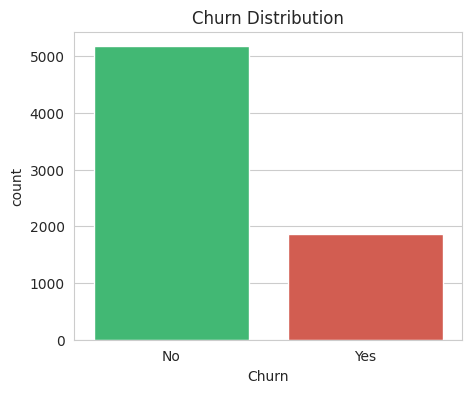

In [12]:
# 1. Overall churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution')
plt.show()

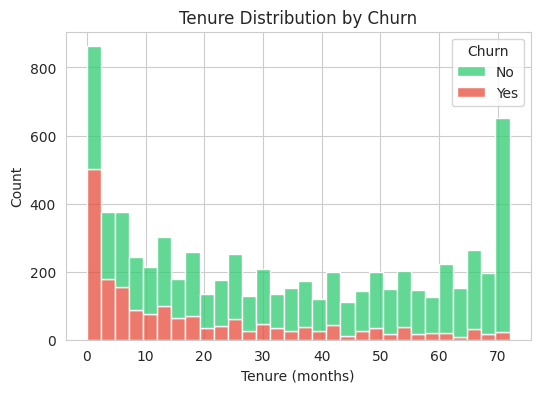

In [13]:
# 2. Tenure vs Churn
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

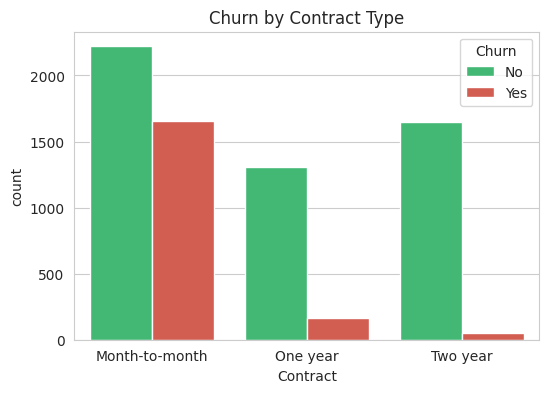

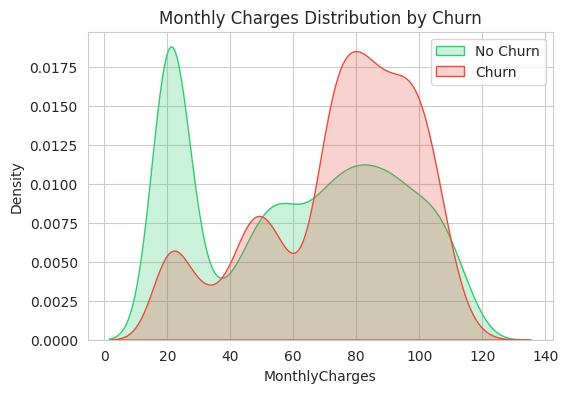

In [14]:
# 3. Contract type vs Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.show()

# 4. Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.kdeplot(data=df[df['Churn']=='No'], x='MonthlyCharges', label='No Churn', fill=True, color='#2ecc71')
sns.kdeplot(data=df[df['Churn']=='Yes'], x='MonthlyCharges', label='Churn', fill=True, color='#e74c3c')
plt.title('Monthly Charges Distribution by Churn')
plt.legend()
plt.show()

In [15]:
# Drop customerID — it's just an identifier, no predictive value
df.drop('customerID', axis=1, inplace=True)

# Convert target variable to binary (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check how many columns are categorical (text) vs numeric
print(df.dtypes.value_counts())
print("\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

object     15
int64       3
float64     2
Name: count, dtype: int64

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
# Step 1: Identify binary vs multi-category columns automatically
binary_cols = [col for col in df.select_dtypes(include='object').columns if df[col].nunique() == 2]
multi_cols = [col for col in df.select_dtypes(include='object').columns if df[col].nunique() > 2]

print("Binary columns:", binary_cols)
print("Multi-category columns:", multi_cols)

# Step 2: Encode binary columns as 0/1
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Step 3: One-hot encode multi-category columns
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("\nNew shape after encoding:", df.shape)
df.head()

Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

New shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [18]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (5634, 30)
Test shape: (1409, 30)

Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


In [19]:
# Install imbalanced-learn if not already available
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression needs scaled features (distance-based math)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_balanced)

# 2. Random Forest (tree-based, doesn't need scaling)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

# 3. XGBoost (also doesn't need scaling)
xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb.fit(X_train_balanced, y_train_balanced)

print("All 3 models trained ✅")

All 3 models trained ✅


In [21]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Get predictions from all 3 models
log_reg_preds = log_reg.predict(X_test_scaled)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# Compare all three
models = {
    'Logistic Regression': (log_reg_preds, log_reg_proba),
    'Random Forest': (rf_preds, rf_proba),
    'XGBoost': (xgb_preds, xgb_proba)
}

for name, (preds, proba) in models.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, proba):.4f}")


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.86      0.79      0.82      1035
       Churn       0.52      0.64      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409

ROC-AUC Score: 0.8080

Random Forest
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1035
       Churn       0.56      0.58      0.57       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC Score: 0.8149

XGBoost
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
       Churn       0.56      0.58      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      

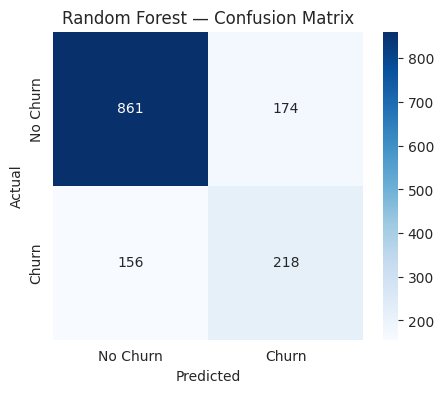

In [22]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

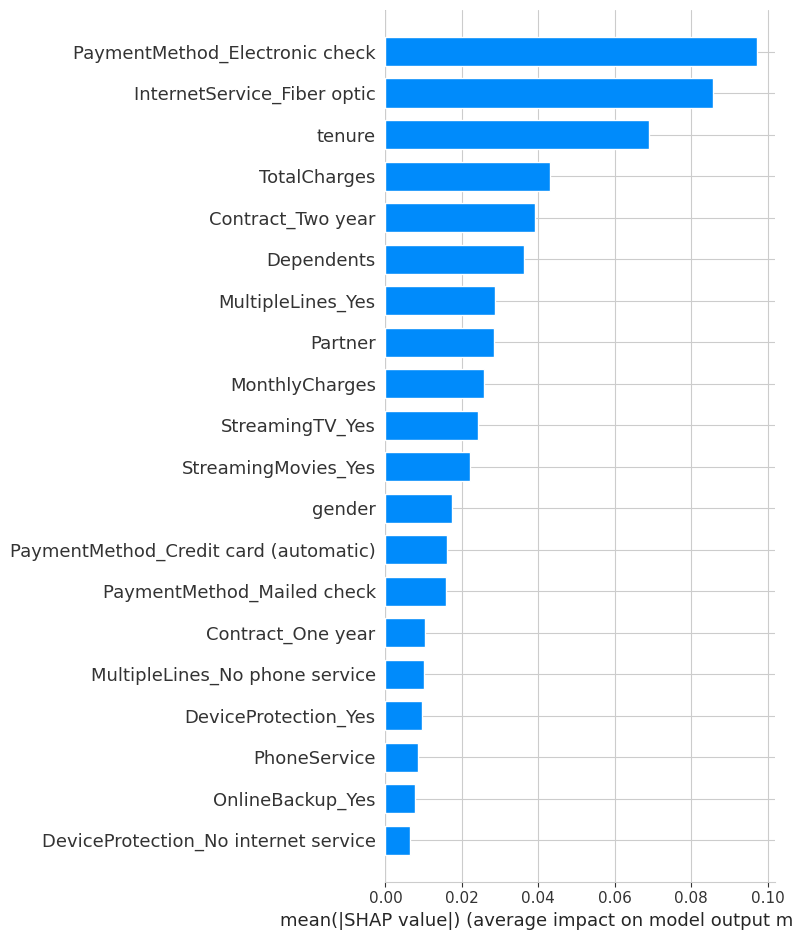

In [23]:
!pip install -q shap
import shap

# Create explainer for Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [class_0, class_1] — we want class 1 (Churn)
shap.summary_plot(shap_values[:,:,1], X_test, plot_type='bar', show=True)

In [24]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, 'churn_model.pkl')

# Also save the list of feature columns — important for making predictions later,
# since new data must have columns in the exact same order
joblib.dump(list(X_train.columns), 'model_features.pkl')

print("Model saved ✅")

Model saved ✅
